## Assignment No.10

# Exploratory Data Analysis

(500, 6)
Drug Dosage (mg)                  float64
Systolic Blood Pressure (mmHg)    float64
Heart Rate (BPM)                  float64
Liver Toxicity Index (U/L)        float64
Blood Glucose Level (mg/dL)       float64
Drug Response                       int64
dtype: object
   Drug Dosage (mg)  Systolic Blood Pressure (mmHg)  Heart Rate (BPM)  \
0         -0.128538                        0.303280         -1.881849   
1         -1.846188                        2.865142         -0.929511   
2         -1.252393                       -1.541613          0.363632   
3          1.992515                       -1.142779         -0.766657   
4          0.377100                        0.538410         -0.029263   

   Liver Toxicity Index (U/L)  Blood Glucose Level (mg/dL)  Drug Response  
0                    0.258286                    -0.792011              1  
1                    2.866786                    -0.719447              1  
2                   -0.325370                     0.191314

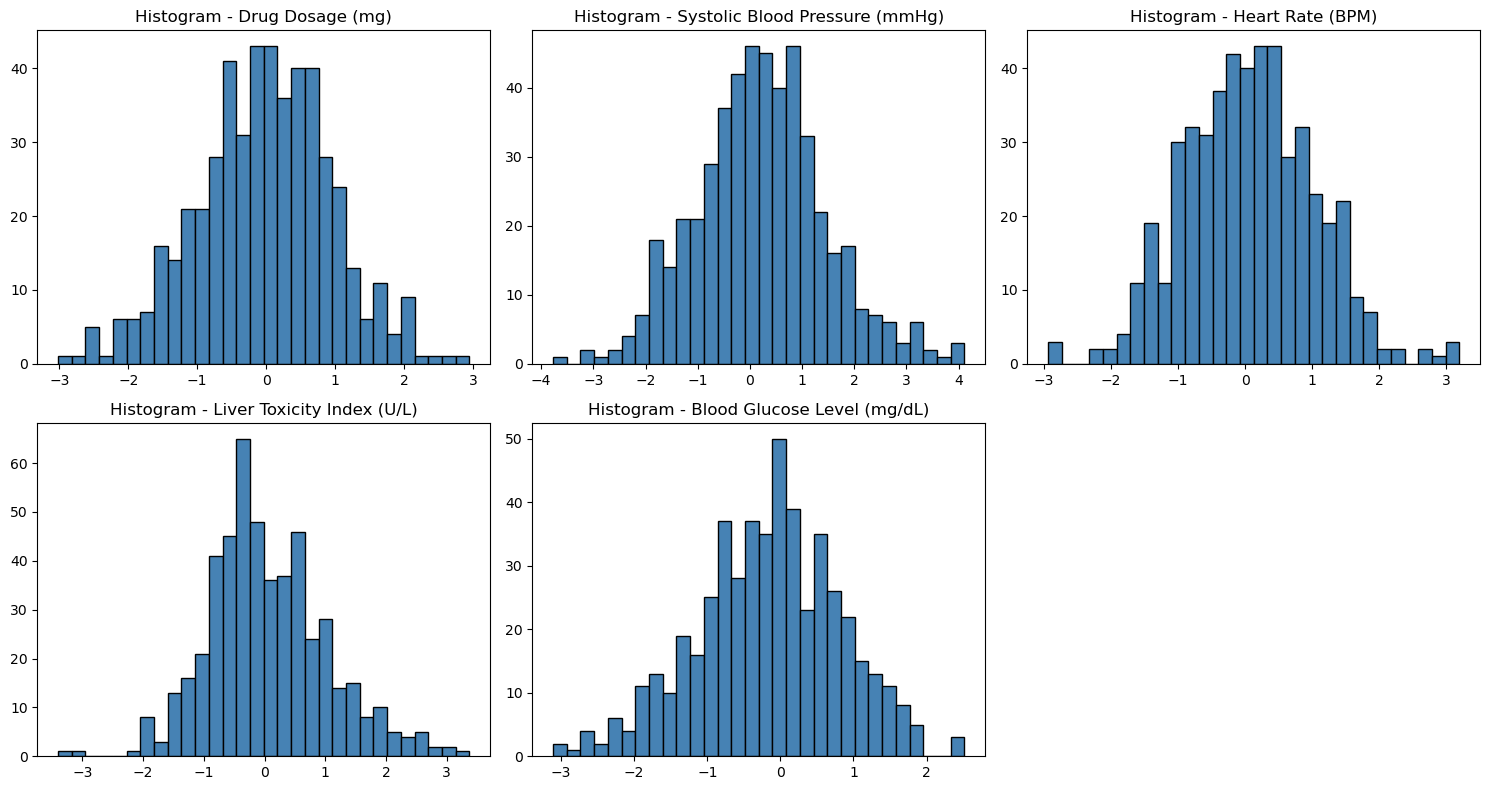

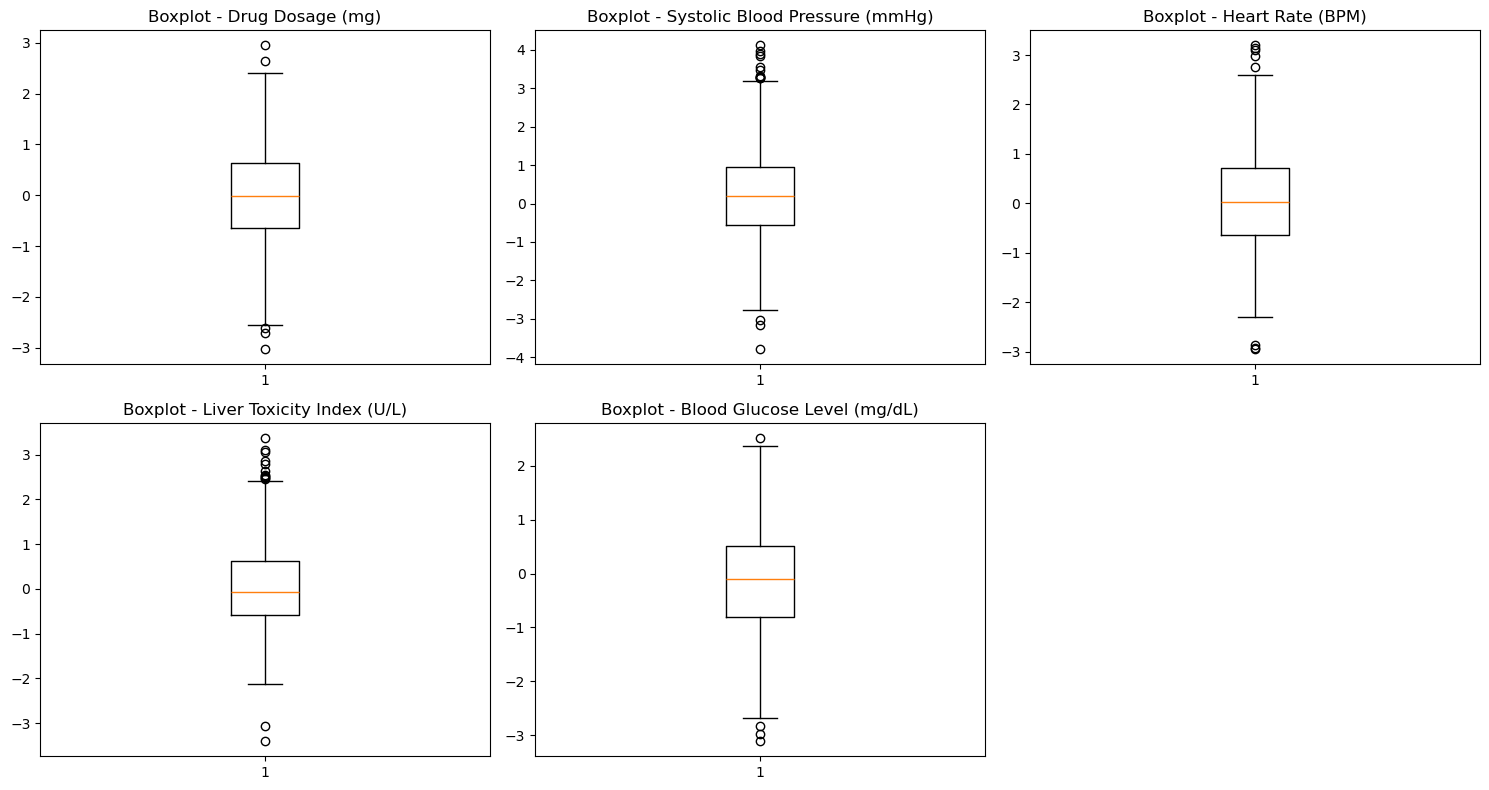

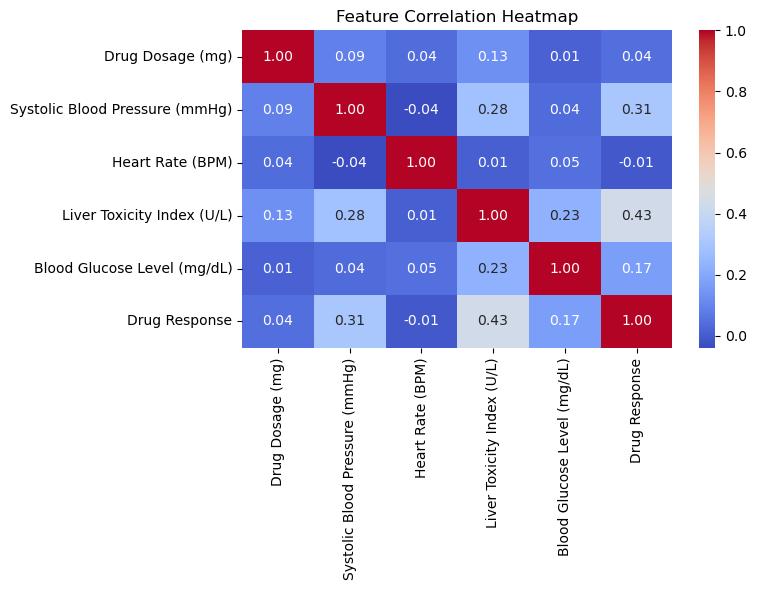

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Pharma_Industry.csv")
print(df.shape)
print(df.dtypes)
print(df.head())
print(df.describe())
print(df.isnull().sum())

df.columns = df.columns.str.strip()
features = df.columns[:-1].tolist()

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i, col in enumerate(features):
    axes[i].hist(df[col], bins=30, color='steelblue', edgecolor='black')
    axes[i].set_title(f'Histogram - {col}')
axes[-1].set_visible(False)
plt.tight_layout()
plt.savefig('histograms.png')
plt.show()

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i, col in enumerate(features):
    axes[i].boxplot(df[col])
    axes[i].set_title(f'Boxplot - {col}')
axes[-1].set_visible(False)
plt.tight_layout()
plt.savefig('boxplots.png')
plt.show()

plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.savefig('correlation_heatmap.png')
plt.show()

# Data Preprocessing

In [2]:
from sklearn.model_selection import train_test_split

X = df.drop('Drug Response', axis=1)
y = df['Drug Response']

print("No categorical variables found - all features are numerical.")
print("Class distribution:\n", y.value_counts())

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

No categorical variables found - all features are numerical.
Class distribution:
 Drug Response
1    260
0    240
Name: count, dtype: int64
Training set size: (400, 5)
Testing set size: (100, 5)


# Data Visualization

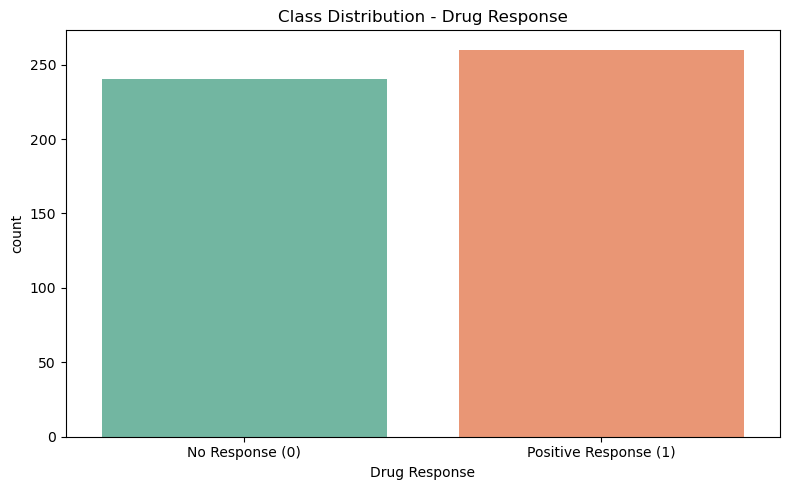

In [ ]:
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split

df = pd.read_csv("Pharma_Industry.csv")
df.columns = df.columns.str.strip()

X = df.drop('Drug Response', axis=1)
y = df['Drug Response']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

plt.figure(figsize=(8, 5))
sns.countplot(x='Drug Response', hue='Drug Response', data=df, palette='Set2', legend=False)
plt.title('Class Distribution - Drug Response')
plt.xticks([0, 1], ['No Response (0)', 'Positive Response (1)'])
plt.tight_layout()
plt.savefig('class_distribution.png')
plt.show()

sns.pairplot(df, hue='Drug Response', palette='Set1', diag_kind='kde', plot_kws={'alpha': 0.5})
plt.suptitle('Pair Plot of Features by Drug Response', y=1.02)
plt.savefig('pairplot.png')
plt.show()

pca_full = PCA(n_components=2)
X_full_pca = pca_full.fit_transform(X)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_full_pca[:, 0], X_full_pca[:, 1], c=y, cmap='bwr', alpha=0.6, edgecolors='k', s=40)
plt.colorbar(scatter, label='Drug Response')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('PCA Scatter Plot (2D) - Drug Response')
plt.tight_layout()
plt.savefig('pca_scatter.png')
plt.show()

# SVM Implementation

Accuracy : 0.78
Precision: 0.7678571428571429
Recall   : 0.8269230769230769
F1-Score : 0.7962962962962963

Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.73      0.76        48
           1       0.77      0.83      0.80        52

    accuracy                           0.78       100
   macro avg       0.78      0.78      0.78       100
weighted avg       0.78      0.78      0.78       100



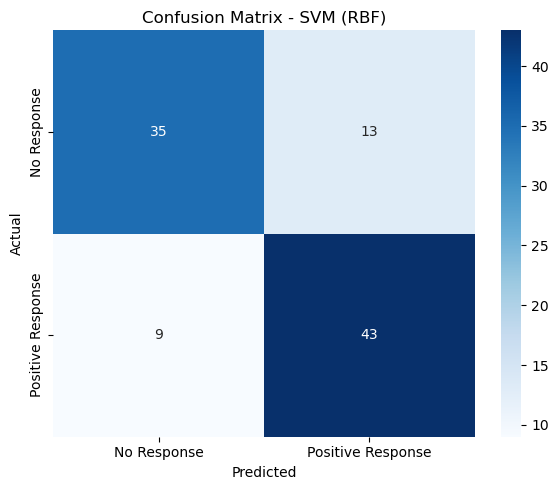

In [4]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

svm_model = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
svm_model.fit(X_train, y_train)
y_pred = svm_model.predict(X_test)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1-Score :", f1_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Response', 'Positive Response'],
            yticklabels=['No Response', 'Positive Response'])
plt.title('Confusion Matrix - SVM (RBF)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('confusion_matrix.png')
plt.show()

# Visualization of SVM Results

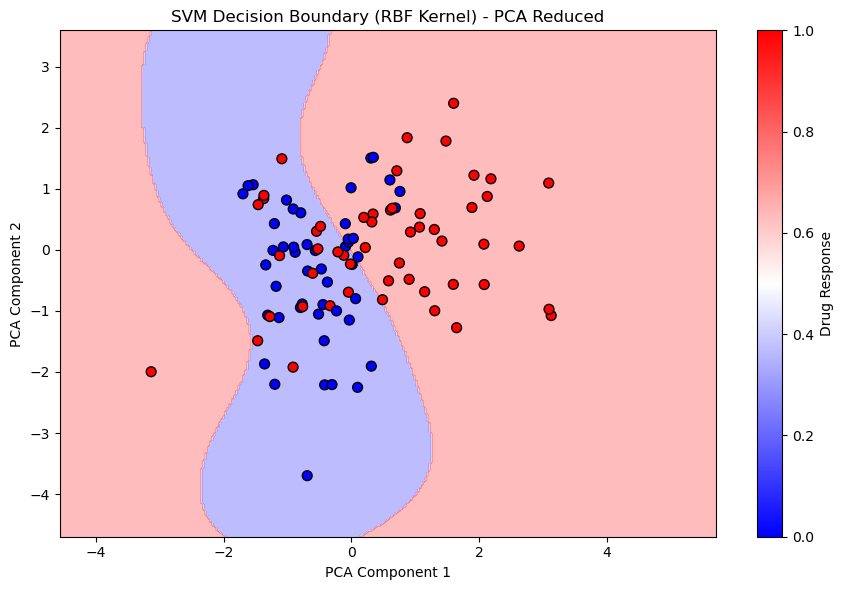

In [5]:
pca2 = PCA(n_components=2)
X_test_pca = pca2.fit_transform(X_test)
X_train_pca = pca2.transform(X_train) if False else pca2.fit_transform(X_test)

pca_full = PCA(n_components=2)
X_full_pca = pca_full.fit_transform(X)
X_test_pca2 = pca_full.transform(X_test)

svm_pca = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
svm_pca.fit(pca_full.transform(X_train), y_train)
y_pred_pca = svm_pca.predict(X_test_pca2)

x_min, x_max = X_full_pca[:, 0].min() - 1, X_full_pca[:, 0].max() + 1
y_min, y_max = X_full_pca[:, 1].min() - 1, X_full_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
Z = svm_pca.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(9, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='bwr')
scatter = plt.scatter(X_test_pca2[:, 0], X_test_pca2[:, 1], c=y_test, cmap='bwr',
                      edgecolors='k', s=50, label='Test Points')
plt.colorbar(scatter, label='Drug Response')
plt.title('SVM Decision Boundary (RBF Kernel) - PCA Reduced')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.tight_layout()
plt.savefig('svm_decision_boundary.png')
plt.show()

# Parameter Tuning and Optimization

In [6]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.01, 0.1],
    'kernel': ['rbf', 'linear', 'poly']
}

grid_search = GridSearchCV(SVC(random_state=42), param_grid, cv=5,
                           scoring='f1', n_jobs=-1, verbose=1)
grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best CV F1 Score:", grid_search.best_score_)

best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test)
print("\nTuned Model Performance:")
print(classification_report(y_test, y_pred_best))

Fitting 5 folds for each of 48 candidates, totalling 240 fits
Best Parameters: {'C': 10, 'gamma': 'auto', 'kernel': 'rbf'}
Best CV F1 Score: 0.7796554706594949

Tuned Model Performance:
              precision    recall  f1-score   support

           0       0.73      0.67      0.70        48
           1       0.71      0.77      0.74        52

    accuracy                           0.72       100
   macro avg       0.72      0.72      0.72       100
weighted avg       0.72      0.72      0.72       100



# Kernel Comparison and Analysis

    Kernel  Accuracy  Precision  Recall  F1-Score
0   linear      0.72     0.7609  0.6731    0.7143
1     poly      0.72     0.7727  0.6538    0.7083
2      rbf      0.78     0.7679  0.8269    0.7963
3  sigmoid      0.68     0.6923  0.6923    0.6923


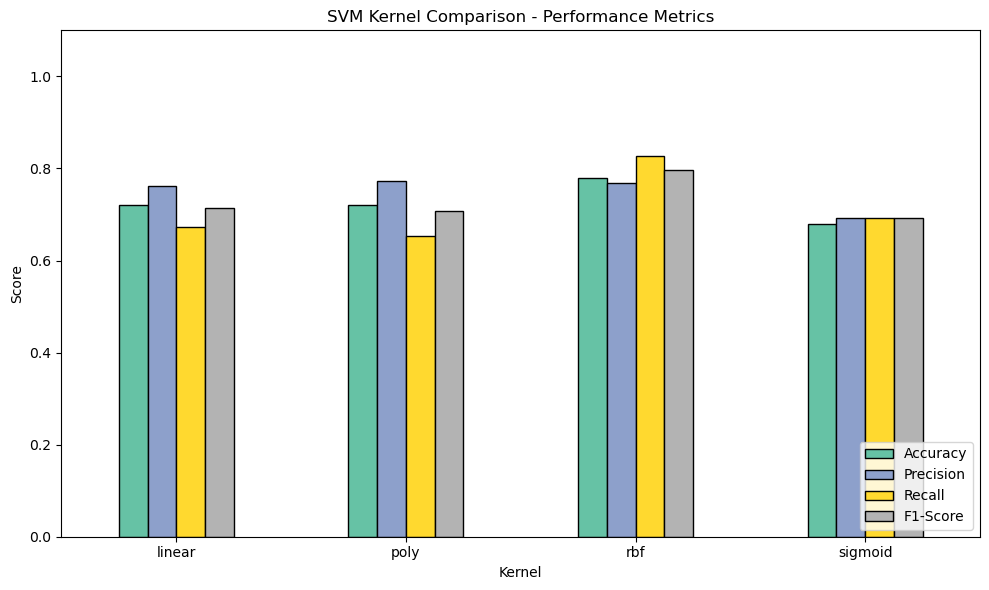

In [9]:
kernels = ['linear', 'poly', 'rbf', 'sigmoid']
results = []

for kernel in kernels:
    model = SVC(kernel=kernel, C=1.0, gamma='scale', random_state=42)
    model.fit(X_train, y_train)
    y_pred_k = model.predict(X_test)
    results.append({
        'Kernel': kernel,
        'Accuracy': round(accuracy_score(y_test, y_pred_k), 4),
        'Precision': round(precision_score(y_test, y_pred_k), 4),
        'Recall': round(recall_score(y_test, y_pred_k), 4),
        'F1-Score': round(f1_score(y_test, y_pred_k), 4)
    })

results_df = pd.DataFrame(results)
print(results_df)

results_df.set_index('Kernel')[['Accuracy', 'Precision', 'Recall', 'F1-Score']].plot(
    kind='bar', figsize=(10, 6), colormap='Set2', edgecolor='black')
plt.title('SVM Kernel Comparison - Performance Metrics')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.ylim(0, 1.1)
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('kernel_comparison.png')
plt.show()